In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

In [3]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print("Shape:", df.shape)
print()

df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:\n")
print(df.describe())

Shape: (1025, 14)

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing Values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target  

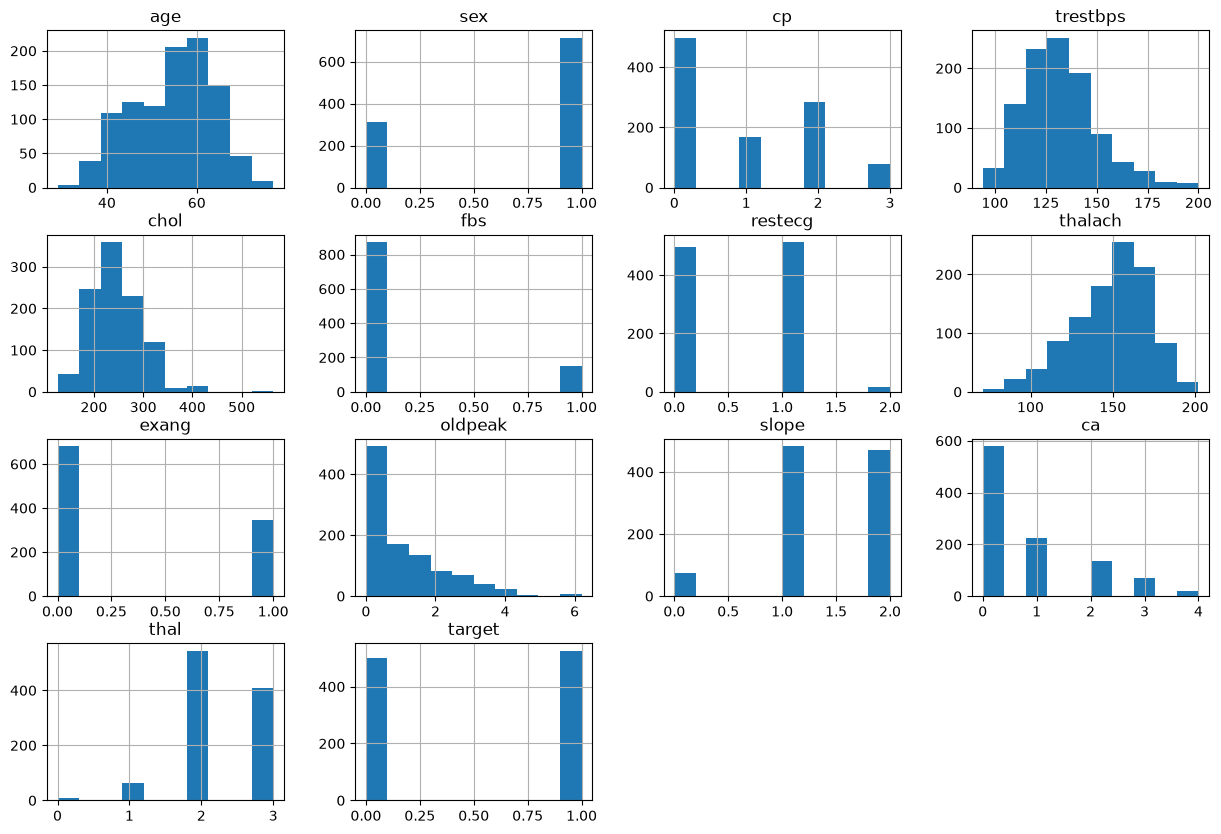

In [5]:
df.hist(figsize=(15,10))
plt.show()

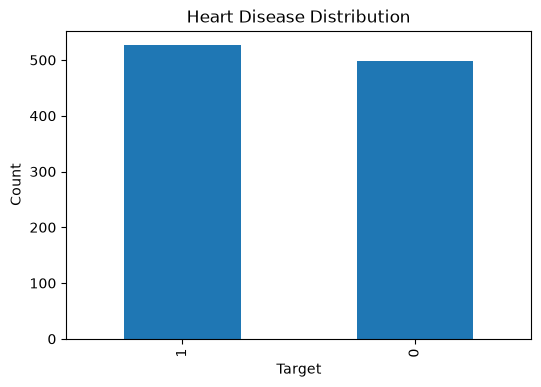

In [6]:
plt.figure(figsize=(6,4))
df["target"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'X' is not defined

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
selector = SelectKBest(score_func=f_classif, k=9)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca',
       'thal'],
      dtype='str')


Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_selected, y_train)

lr_pred = lr_model.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Accuracy: 0.8

Confusion Matrix
[[74 28]
 [13 90]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_selected, y_train)

dt_pred = dt_model.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report")
print(classification_report(y_test, dt_pred))

Accuracy: 0.9853658536585366

Confusion Matrix
[[102   0]
 [  3 100]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_selected, y_train)

rf_pred = rf_model.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy: 0.9853658536585366

Confusion Matrix
[[102   0]
 [  3 100]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_selected, y_train)

knn_pred = knn_model.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

Accuracy: 0.8731707317073171

Confusion Matrix
[[82 20]
 [ 6 97]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       102
           1       0.83      0.94      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205



Comparing Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree,0.985366
2,Random Forest,0.985366
3,KNN,0.873171
0,Logistic Regression,0.800000


After evaluating all the machine learning models, we compare their performance based on accuracy and overall prediction capability. Although both the Decision Tree and Random Forest models achieved high accuracy, the Random Forest Classifier is selected as the final model because it is more robust, less prone to overfitting, and generally provides better performance on unseen data by combining the predictions of multiple decision trees.

The trained Random Forest model, along with the preprocessing objects (StandardScaler and Feature Selector), will now be saved using the joblib library. Saving these files allows the model to be reused later for deployment and making predictions on new patient data without retraining.

In [ ]:
joblib.dump(rf_model, "heart_disease_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "feature_selector.pkl")

print("Files saved successfully.")

Files saved successfully.


In [ ]:
loaded_model = joblib.load("heart_disease_rf_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selector = joblib.load("feature_selector.pkl")

In [ ]:
new_patient = pd.DataFrame([{
    "age":52,
    "sex":1,
    "cp":2,
    "trestbps":150,
    "chol":240,
    "fbs":0,
    "restecg":1,
    "thalach":150,
    "exang":0,
    "oldpeak":1.2,
    "slope":2,
    "ca":0,
    "thal":2
}])

new_scaled = loaded_scaler.transform(new_patient)
new_selected = loaded_selector.transform(new_scaled)

prediction = loaded_model.predict(new_selected)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Heart Disease Detected


In [ ]:
import joblib

joblib.dump(rf_model, "heart_disease_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "feature_selector.pkl")

print("Model, scaler, and feature selector saved successfully!")

Model, scaler, and feature selector saved successfully!


In [ ]:
import os

print(os.listdir())

['.git', 'feature_selector.pkl', 'heart.csv', 'Heart_Disease_Prediction.ipynb', 'heart_disease_rf_model.pkl', 'README.md', 'scaler.pkl']


In [ ]:
loaded_model = joblib.load("heart_disease_rf_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selector = joblib.load("feature_selector.pkl")

print("Files loaded successfully!")

Files loaded successfully!


In [ ]:
new_patient = pd.DataFrame([{
    "age": 52,
    "sex": 1,
    "cp": 2,
    "trestbps": 150,
    "chol": 240,
    "fbs": 0,
    "restecg": 1,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.2,
    "slope": 2,
    "ca": 0,
    "thal": 2
}])

new_scaled = loaded_scaler.transform(new_patient)
new_selected = loaded_selector.transform(new_scaled)

prediction = loaded_model.predict(new_selected)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Heart Disease Detected


In [8]:
import pandas as pd

df = pd.read_csv("heart.csv")

In [9]:
print(df["target"].value_counts())

target
1    526
0    499
Name: count, dtype: int64


In [12]:
new_patient = pd.DataFrame([{
    "age": 35,
    "sex": 0,
    "cp": 2,
    "trestbps": 118,
    "chol": 180,
    "fbs": 0,
    "restecg": 0,
    "thalach": 175,
    "exang": 0,
    "oldpeak": 0.0,
    "slope": 0,
    "ca": 0,
    "thal": 1
}])

new_scaled = scaler.transform(new_patient)
new_selected = selector.transform(new_scaled)

print("Prediction:", rf_model.predict(new_selected))
print("Probability:", rf_model.predict_proba(new_selected))

Prediction: [1]
Probability: [[0.03 0.97]]


In [13]:
print(selected_features)

NameError: name 'selected_features' is not defined

In [14]:
import joblib

rf_model = joblib.load("heart_disease_rf_model.pkl")
scaler = joblib.load("scaler.pkl")
selector = joblib.load("feature_selector.pkl")

print("Number of features selected:", selector.get_support().sum())
print("Selected feature indices:", selector.get_support(indices=True))

Number of features selected: 9
Selected feature indices: [ 0  1  2  7  8  9 10 11 12]


In [15]:
print("Selector mask:")
print(selector.get_support())

Selector mask:
[ True  True  True False False False False  True  True  True  True  True
  True]


In [16]:
selector = SelectKBest(score_func=f_classif, k=9)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

NameError: name 'X_train_scaled' is not defined

In [17]:
predictions = rf_model.predict(X_test_selected)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

NameError: name 'X_test_selected' is not defined

In [18]:
import joblib

rf_model = joblib.load("heart_disease_rf_model.pkl")
scaler = joblib.load("scaler.pkl")
selector = joblib.load("feature_selector.pkl")

healthy = df[df["target"] == 0].iloc[[0]]

print("Healthy record:")
print(healthy)

patient = healthy.drop(columns=["target"])

patient_scaled = scaler.transform(patient)
patient_selected = selector.transform(patient_scaled)

print("Prediction:", rf_model.predict(patient_selected))
print("Probability:", rf_model.predict_proba(patient_selected))

Healthy record:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   

   ca  thal  target  
0   2     3       0  
Prediction: [0]
Probability: [[0.99 0.01]]


In [11]:
import joblib

rf_model = joblib.load("heart_disease_rf_model.pkl")
scaler = joblib.load("scaler.pkl")
selector = joblib.load("feature_selector.pkl")